In [ ]:
!pip install numpy==2.2.6 \
             torch==2.6.0 \
             torchvision==0.21.0 \
             nltk==3.9.4 \
             spacy==3.8.14 \
             matplotlib==3.10.9 \
             tqdm==4.67.3 \
             transformers==5.9.0 \
             datasets==4.8.5 \
             scikit-learn==1.7.2 
!python -m spacy download en_core_web_sm

## Халюцинации
Ти си изследовател в лаборатория за изкуствен интелект и ръководиш важен проект за създаване на мащабен мултимодален набор от данни. За да автоматизирате и ускорите процеса, екипът ти е използвал Голям езиков модел (LLM), който да генерира текстови описания (captions) за стотици хиляди изображения.

За съжаление, при анотиране на данни от LLM често се получават сериозни отклонения. Вследствие на дефекти в декодирането или липса на достатъчно визуален контекст, моделът понякога започва да "халюцинира" обекти, които изобщо не съществуват на снимката (например, твърди, че вижда куче, когато на нея има котка), или генерира напълно несвързан и нелогичен текст (incoherent text). Твоята задача е да изчистиш този набор от данни, като създадеш стабилен филтър, който да разпознава дали дадено описание е коректно, халюцинирано или напълно несвързано.
### Задача и ограничения
Системата, която разработваш, ще бъде интегрирана в среда с изключително строги лимити за памет и изчислително време. Затова главният инженер на проекта е наложил следните железни правила за твоето решение:
- Фиксиран класификатор: Задължително трябва да използваш предварително зададения **GradientBoostingClassifier**. Абсолютно е забранено да променяш неговите хиперпараметри или да добавяш други модели (като невронни мрежи) към пайплайна за класификация.

- Брой характеристики: Имаш право да конструираш и подадеш максимум **16 features** (характеристики) към класификатора. Ще трябва внимателно да подбереш кои метрики носят най-много семантична и визуална информация.

- Без обучение: Позволяват се само методи **без контролирано обучение (unsupervised learning only allowed)** с етикетите на **примерите от данните** за конструиране на характеристиките

- Библиотеки: За извличането на тези характеристики можеш да използваш единствено:
    - `transfomers` – за извличане на ембединги и пресмятане на семантичната близост между изображението и текста, но само и единствено зареденият модел.
    - `nltk` – като е позволено само използването на изтегления модул `punkt` за токенизация.
    - `torch`и `numpy` - За обработка на ембедингите, но не и за трениране
    - `spacy` – за по-дълбок лингвистичен анализ (import spacy и зареждане на модела чрез `nlp = spacy.load("en_core_web_sm")`).

Никакви други външни библиотеки не са позволени!

### Данни
Наборът от данни се зарежда чрез библиотеката `datasets` (чрез `load_from_disk`) и съдържа следните ключови полета за всеки пример:
- `image`: Изображението (PIL Image).
- `caption`: Текстовото описание, генерирано от LLM.
- `label`: Целевият клас, който трябва да предскажеш (0, 1 или 2).

Етикетите отговарят на трите възможни състояния на текста:
- Клас 0: Коректно описание.
- Клас 1: Халюцинация (подменено съществително).
- Клас 2: Несвързан текст (разбъркани думи).

За твоите експерименти разполагаш с тренировъчен (train) и валидационен (val) сплит. Препоръчително е да разгледаш суровите данни, за да придобиеш интуиция за разликите между класовете, преди да започнеш с извличането на характеристиките.
### Налични инструменти

За да те улеснят поне малко в задачата, старшите изследователи от екипа са ти подготвили помощна функция. Тя използва spacy и автоматично връща частите на речта (Part-of-Speech tags) на думите в подаденото изречение.

Твоята цел е креативно да комбинираш тази лингвистична информация (структура на изречението, брой съществителни, граматическа коректност) с визуалното разбиране на CLIP (дали текстът реално отговаря на снимката), за да "събереш" перфектните 64 характеристики и да спасиш данните на лабораторията!
### Оценяване

Оценяването се изпълнява на скрит набор от данни (test split), а водещата метрика за класиране на моделите е F1 macro, за да се гарантира еднакво добро разпознаване и на трите класа.

In [5]:
import numpy as np
import torch
import nltk
import spacy
import matplotlib.pyplot as plt

from tqdm import tqdm
from transformers import CLIPProcessor, CLIPModel
from datasets import load_from_disk

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

In [6]:
# 1. NLTK Setup
print("Изтегляне на NLTK ресурси (punkt)...")
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# 2. spaCy Setup
print("Зареждане на spaCy (en_core_web_sm)...")
nlp = spacy.load("en_core_web_sm")

# 3. Зареждане на данните (Локално)
print("Зареждане на тренировъчните и валидационните данни...")
labeled_data = load_from_disk("./alignment_competition_data/labeled")
print(f"Успешно заредени сплитове: {list(labeled_data.keys())}")

# 4. CLIP Setup
print("Инициализация на CLIP модела...")
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Използвано устройство (Device): {device.upper()}")

model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id).to(device)
model.eval() 

print("Всички ресурси и данни са заредени успешно!")

Изтегляне на NLTK ресурси (punkt)...
Зареждане на spaCy (en_core_web_sm)...
Зареждане на тренировъчните и валидационните данни...
Успешно заредени сплитове: ['train', 'val']
Инициализация на CLIP модела...
Използвано устройство (Device): MPS


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 56971.88it/s]


Всички ресурси и данни са заредени успешно!


### Визуализация


Пример 1
Етикет (Label): 0: Оригинал (Коректно)
Текст (Caption): An empty room containing a table with a computer on it.
------------------------------------------------------------
Части на речта (POS Tags):
An (DET) | empty (ADJ) | room (NOUN) | containing (VERB) | a (DET) | table (NOUN) | with (ADP) | a (DET) | computer (NOUN) | on (ADP) | it (PRON) | . (PUNCT)


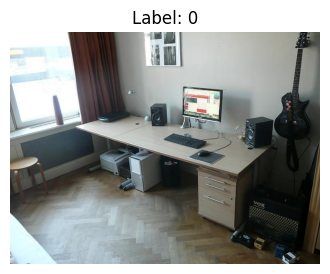


Пример 811
Етикет (Label): 1: Сменен обект (Халюцинация)
Текст (Caption): Black/grayish dog lays down inside opened red suitcase
------------------------------------------------------------
Части на речта (POS Tags):
Black (ADJ) | / (SYM) | grayish (ADJ) | dog (NOUN) | lays (VERB) | down (ADP) | inside (ADV) | opened (VERB) | red (ADJ) | suitcase (NOUN)


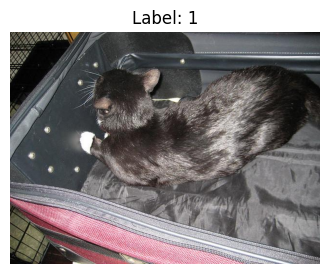

In [7]:
# Помощна функция, предоставена от старшите изследователи :)
def get_pos_tags(text):
    """
    Анализира текст и връща списък с думите и техните части на речта.
    Използва вече заредения spaCy модел (nlp) от предходната клетка.
    """
    doc = nlp(text)
    # Генерираме четим формат: "дума (ЧАСТ_НА_РЕЧТА)"
    return [f"{token.text} ({token.pos_})" for token in doc]

# Речник за по-лесно разчитане на класовете
label_map = {
    0: "0: Оригинал (Коректно)",
    1: "1: Сменен обект (Халюцинация)",
    2: "2: Разбъркани думи (Несвързано)"
}

# Визуализираме точно 2 примера
for i in [0, 810]:
    sample = labeled_data["train"][i]
    image = sample["image"]
    caption = sample["caption"]
    label = sample["label"]
    
    print("\n" + "="*60)
    print(f"Пример {i+1}")
    print(f"Етикет (Label): {label_map.get(label, 'Неизвестен')}")
    print(f"Текст (Caption): {caption}")
    print("-" * 60)
    
    # Извикваме помощната функция
    pos_tags = get_pos_tags(caption)
    print("Части на речта (POS Tags):")
    print(" | ".join(pos_tags))
    print("="*60)
    
    # Показваме самото изображение
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

### Решение

In [ ]:
import random
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import Laplace

def extract_features(dataset_split, batch_size=64, is_train=False):
    
    if not hasattr(extract_features, "pos_lm"):
        extract_features.pos_lm = None
        extract_features.noun_vocab = None
        extract_features.vocab_embs = None

    # --- Помощни функции ---
    def get_pos_entropies(tags: list[str], lm) -> tuple[float, float]:
        if len(tags) <= 2:
            return 20.0, 20.0 
        padded = list(nltk.lm.preprocessing.pad_both_ends(tags, n=3))
        return (
            lm.entropy(list(nltk.ngrams(padded, 2))),
            lm.entropy(list(nltk.ngrams(padded, 3))),
        )

    def get_contrastive_features(nouns, img_embed, noun_vocab, vocab_embs, k=10):
        if not nouns:
            return 0.0, 0.0, 0.0, float(len(noun_vocab)), 1.0, 0.0, 0.0

        noun_to_idx = {n: i for i, n in enumerate(noun_vocab)}
        img_cpu = img_embed.cpu()
        improvements, ranks, percentiles, neighbour_stds, neighbour_peaks = [], [], [], [], []

        for noun in nouns:
            if noun not in noun_to_idx:
                continue
            idx = noun_to_idx[noun]
            noun_emb = vocab_embs[idx]

            text_sims = (vocab_embs * noun_emb).sum(dim=-1)
            text_sims[idx] = -2.0
            top_k = text_sims.topk(k).indices

            current_sim = (img_cpu * noun_emb).sum().item()
            neighbour_img_sims = (img_cpu * vocab_embs[top_k]).sum(dim=-1)
            improvements.append(neighbour_img_sims.max().item() - current_sim)

            img_sims_all = (vocab_embs * img_cpu).sum(dim=-1)
            rank = int((img_sims_all > img_sims_all[idx].item()).sum().item()) + 1
            ranks.append(rank)
            percentiles.append(rank / len(noun_vocab))

            neighbour_stds.append(float(neighbour_img_sims.std().item()))
            neighbour_peaks.append(float((neighbour_img_sims.max() - neighbour_img_sims.mean()).item()))

        if not improvements:
            return 0.0, 0.0, 0.0, float(len(noun_vocab)), 1.0, 0.0, 0.0

        return (
            float(max(improvements)), float(np.mean(improvements)), float(min(improvements)),
            float(np.mean(ranks)), float(np.mean(percentiles)),
            float(np.mean(neighbour_stds)), float(np.mean(neighbour_peaks))
        )

    if is_train:
        print("[1/3] Изчисляване на 'Perturbation Similarity' за филтриране на данните...")
        captions = dataset_split["caption"]
        sim_scores = []
        
        # Обработваме текстовете на бачове, за да намерим сходството между оригинала и разбъркания вариант
        for i in tqdm(range(0, len(captions), batch_size), desc="Филтриране"):
            batch_caps = captions[i : i + batch_size]
            
            # Създаваме изкуствено разбъркани версии (фиксираме seed за повторяемост)
            shuffled_caps = []
            for cap in batch_caps:
                words = cap.split()
                random.Random(42).shuffle(words)
                shuffled_caps.append(" ".join(words))
                
            inputs_orig = processor(text=batch_caps, return_tensors="pt", padding=True).to(device)
            inputs_shuf = processor(text=shuffled_caps, return_tensors="pt", padding=True).to(device)
            
            with torch.no_grad():
                emb_orig = model.text_model(**inputs_orig).pooler_output
                emb_orig = model.text_projection(emb_orig)
                emb_orig = emb_orig / emb_orig.norm(p=2, dim=-1, keepdim=True)
                
                emb_shuf = model.text_model(**inputs_shuf).pooler_output
                emb_shuf = model.text_projection(emb_shuf)
                emb_shuf = emb_shuf / emb_shuf.norm(p=2, dim=-1, keepdim=True)
                
                # Косинусово сходство между оригинал и разбъркан текст
                batch_sims = (emb_orig * emb_shuf).sum(dim=-1).cpu().numpy()
                sim_scores.extend(batch_sims)
        
        # Взимаме прага за долните 66% (тези, при които редът на думите има най-голямо значение)
        threshold = np.percentile(sim_scores, 66)
        valid_captions = [captions[i] for i in range(len(captions)) if sim_scores[i] <= threshold]
        
        print(f"Открити {len(valid_captions)} 'чисти' изречения от общо {len(captions)}.")
        
        print("[2/3] Обучение на POS Ентропия върху филтрираните данни...")
        docs = list(nlp.pipe(valid_captions))
        valid_pos_sequences = [[t.tag_ for t in doc] for doc in docs]
        
        train_data, padded_vocab = padded_everygram_pipeline(3, valid_pos_sequences)
        extract_features.pos_lm = Laplace(3)
        extract_features.pos_lm.fit(train_data, padded_vocab)
        
        print("[3/3] Векторизиране на глобалния речник (върху всички данни)...")
        vocab = set()
        all_docs = list(nlp.pipe(captions))
        for doc in all_docs:
            vocab.update([t.text.lower() for t in doc if t.pos_ in ("NOUN", "PROPN") and not t.is_stop and len(t.text) > 2])
            
        extract_features.noun_vocab = sorted(vocab)
        all_embs = []
        probes = [f"a {n}" for n in extract_features.noun_vocab]
        for i in tqdm(range(0, len(probes), 256), desc="Embedding noun vocab"):
            inp = processor(text=probes[i:i+256], return_tensors="pt", padding=True).to(device)
            with torch.no_grad():
                pooled = model.text_model(**inp).pooler_output
                emb = model.text_projection(pooled)
                emb = emb / emb.norm(p=2, dim=-1, keepdim=True)
            all_embs.append(emb.cpu())
            
        extract_features.vocab_embs = torch.cat(all_embs, dim=0)

    # =========================================================
    # 2. ИЗВЛИЧАНЕ (Главният цикъл)
    # =========================================================
    X = []
    for i in tqdm(range(0, len(dataset_split), batch_size), desc="Извличане на характеристики"):
        batch = dataset_split[i : i + batch_size]
        images = batch["image"]
        captions = batch["caption"]

        docs = list(nlp.pipe(captions))
        batch_tags = [[t.tag_ for t in doc] for doc in docs]
        batch_nouns = [[t.text.lower() for t in doc if t.pos_ in ("NOUN", "PROPN") and not t.is_stop and len(t.text) > 2] for doc in docs]

        inputs = processor(text=captions, images=images, return_tensors="pt", padding=True).to(device)
        
        with torch.no_grad():
            out = model(**inputs)
            img_embeds = out.image_embeds / out.image_embeds.norm(p=2, dim=-1, keepdim=True)
            txt_embeds = out.text_embeds / out.text_embeds.norm(p=2, dim=-1, keepdim=True)
            cos_sims = (img_embeds * txt_embeds).sum(dim=-1).cpu().numpy()

        for idx in range(len(captions)):
            # Връщаме любимата POS Ентропия (вече обучена върху перфектни данни)
            bi_ent, tri_ent = get_pos_entropies(batch_tags[idx], extract_features.pos_lm)
            
            cn_max, cn_mean, cn_min, cn_rank, cn_pct, cn_std, cn_peak = get_contrastive_features(
                batch_nouns[idx], 
                img_embeds[idx : idx + 1], 
                extract_features.noun_vocab, 
                extract_features.vocab_embs
            )
            
            X.append([
                bi_ent, tri_ent, float(cos_sims[idx]),
                cn_max, cn_mean, cn_min, cn_rank, cn_pct, cn_std, cn_peak
            ])

    return np.array(X)

### Оценяване

In [ ]:
# ==========================================
# ВНИМАНИЕ: АБСОЛЮТНО Е ЗАБРАНЕНО ДА ПРОМЕНЯТЕ ТОЗИ БЛОК!
# ==========================================
BATCH_SIZE = 64

print("--- Обработка на Train Split ---")
y_train = np.array(labeled_data["train"]["label"])
safe_train_data = labeled_data["train"].remove_columns("label")
X_train = extract_features(safe_train_data, batch_size=BATCH_SIZE, is_train=True)


print("\n--- Обработка на Val Split ---")
y_val = np.array(labeled_data["val"]["label"])
safe_val_data = labeled_data["val"].remove_columns("label")
X_val = extract_features(safe_val_data, batch_size=BATCH_SIZE)


# Проверка за позволения брой характеристики
assert X_train.shape[1] <= 16, f"Грешка: Използвате {X_train.shape[1]} характеристики, а лимитът е 16!"

print("\nОбучение на фиксирания Gradient Boosting Classifier...")

# Използваме пайплайн със StandardScaler за числена стабилност
clf = make_pipeline(
    StandardScaler(),
    GradientBoostingClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        max_features="sqrt",
        min_samples_leaf=5,
        random_state=42,
    ),
)

# Тренираме модела
clf.fit(X_train, y_train)

# Предсказваме върху валидационния сет
y_val_pred = clf.predict(X_val)

# Изчисляване на водещите метрики
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average="macro")

print("\n" + "=" * 50)
print(" (VALIDATION REPORT)")
print("=" * 50)
print(
    classification_report(
        y_val, y_val_pred, target_names=["0: Коректно", "1: Халюцинация", "2: Несвързано"]
    )
)
print("-" * 50)
print(f"Обща Точност (Accuracy): {val_accuracy:.4f}")
print(f"Водеща Метрика (Macro F1): {val_f1_macro:.4f}")
print("-" * 50)
print("\nМатрица на грешките (Confusion Matrix):")
print(confusion_matrix(y_val, y_val_pred))

--- Обработка на Train Split ---
[1/3] Изчисляване на 'Perturbation Similarity' за филтриране на данните...


Филтриране: 100%|██████████| 38/38 [00:06<00:00,  5.65it/s]


Открити 1584 'чисти' изречения от общо 2400.
[2/3] Обучение на POS Ентропия върху филтрираните данни...
[3/3] Векторизиране на глобалния речник (върху всички данни)...


Извличане на характеристики: 100%|██████████| 38/38 [00:39<00:00,  1.03s/it]



--- Обработка на Val Split ---


Извличане на характеристики: 100%|██████████| 10/10 [00:10<00:00,  1.02s/it]



Обучение на фиксирания Gradient Boosting Classifier...

 (VALIDATION REPORT)
                precision    recall  f1-score   support

   0: Коректно       0.74      0.76      0.75       200
1: Халюцинация       0.76      0.74      0.75       200
 2: Несвързано       0.92      0.92      0.92       200

      accuracy                           0.81       600
     macro avg       0.81      0.81      0.81       600
  weighted avg       0.81      0.81      0.81       600

--------------------------------------------------
Обща Точност (Accuracy): 0.8050
Водеща Метрика (Macro F1): 0.8051
--------------------------------------------------

Матрица на грешките (Confusion Matrix):
[[151  40   9]
 [ 44 149   7]
 [  9   8 183]]
